In [2]:

import os
import random
from collections import Counter
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


In [ ]:

import os
print(os.listdir(DATASET_PATH))

['cardboard', 'e-waste', 'glass', 'metal', 'organic', 'paper', 'plastic', 'README.md', 'textile', 'trash']


In [ ]:

# auto enter nested folders
while True:
    items = os.listdir(DATASET_PATH)
    if len(items) == 1 and os.path.isdir(os.path.join(DATASET_PATH, items[0])):
        DATASET_PATH = os.path.join(DATASET_PATH, items[0])
    else:
        break

print("Final Path:", DATASET_PATH)

Final Path: /mnt/d/waste-classification-system-II/dataset/New Trash Classfication Dataset/new-dataset-trash-type-v2


In [22]:


DATASET_PATH = "/mnt/d/waste-classification-system-II/dataset/New Trash Classfication Dataset/new-dataset-trash-type-v2"

In [9]:
# ENTER CODE HERE

from collections import Counter
import cv2
import matplotlib.pyplot as plt

class_counts = Counter()
image_sizes = []
sample_images = {}

for item in os.listdir(DATASET_PATH):
    item_path = os.path.join(DATASET_PATH, item)

    # train/test case
    if item.lower() in ["train", "test", "val"]:
        for cls in os.listdir(item_path):
            class_path = os.path.join(item_path, cls)

            if not os.path.isdir(class_path):
                continue

            images = os.listdir(class_path)
            class_counts[cls] += len(images)

            for img_name in images[:50]:
                img = cv2.imread(os.path.join(class_path, img_name))
                if img is None:
                    continue

                h, w, _ = img.shape
                image_sizes.append((h, w))

            if cls not in sample_images and len(images) > 0:
                sample_images[cls] = os.path.join(class_path, images[0])

    # direct class folders
    else:
        class_path = item_path

        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)
        class_counts[item] += len(images)

        for img_name in images[:50]:
            img = cv2.imread(os.path.join(class_path, img_name))
            if img is None:
                continue

            h, w, _ = img.shape
            image_sizes.append((h, w))

        if item not in sample_images and len(images) > 0:
            sample_images[item] = os.path.join(class_path, images[0])

In [24]:
# ENTER CODE HERE

count = 0

for cls in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, cls)

    # 🔥 important fix
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        count += 1

print("Total Images:", count)

Total Images: 8407


In [10]:
# ENTER CODE HERE

print("Total Classes:", len(class_counts))
print("Classes:", list(class_counts.keys()))

Total Classes: 9
Classes: ['cardboard', 'e-waste', 'glass', 'metal', 'organic', 'paper', 'plastic', 'textile', 'trash']


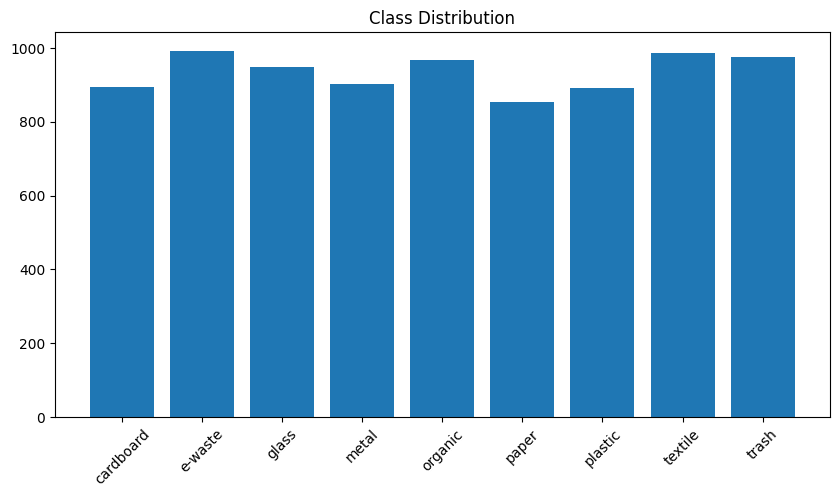

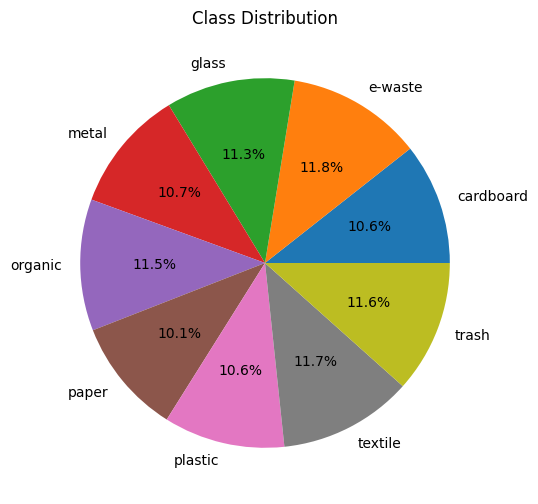

In [11]:
# ENTER CODE HERE

plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

plt.figure(figsize=(6,6))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

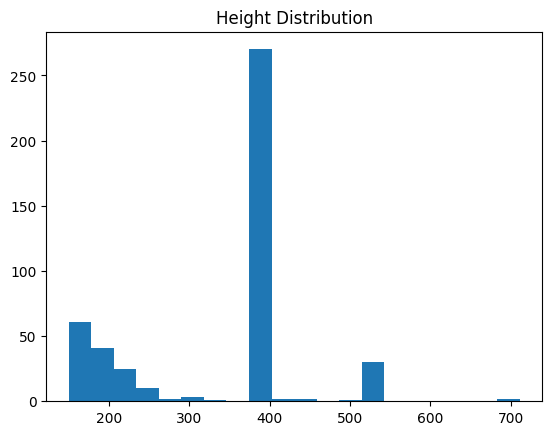

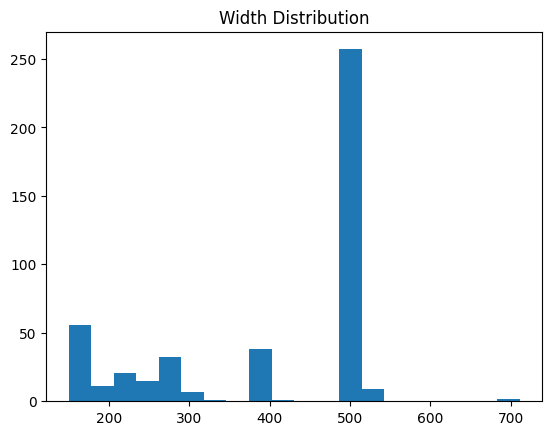

In [12]:
# ENTER CODE HERE

heights = [s[0] for s in image_sizes]
widths = [s[1] for s in image_sizes]

plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.show()

plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.show()

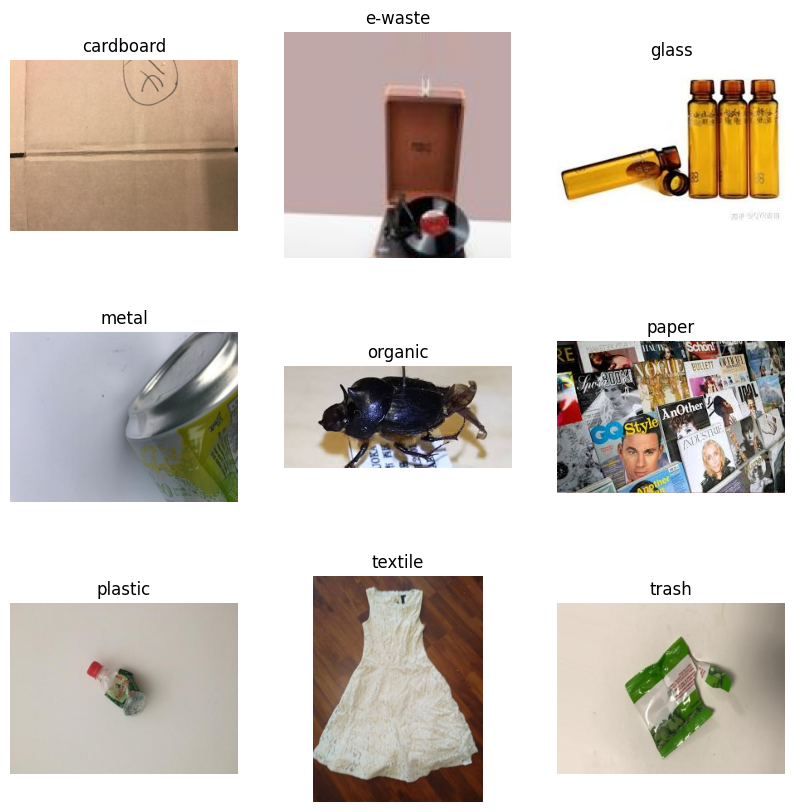

In [13]:
# ENTER CODE HERE

import random

plt.figure(figsize=(10,10))

i = 1
for cls, img_path in sample_images.items():
    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

    i += 1
    if i > 9:
        break

plt.show()

### Image Resolution Analysis

In [14]:


heights = [s[0] for s in image_sizes]
widths = [s[1] for s in image_sizes]

print("Min Height:", min(heights))
print("Max Height:", max(heights))
print("Min Width:", min(widths))
print("Max Width:", max(widths))

Min Height: 150
Max Height: 711
Min Width: 150
Max Width: 711


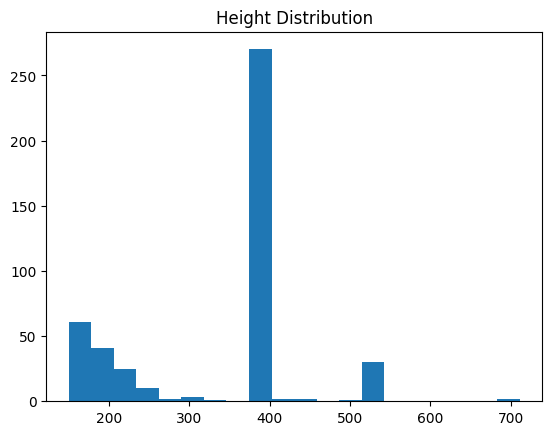

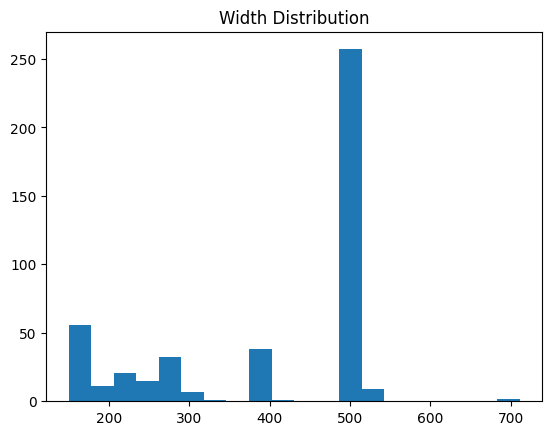

In [ ]:


plt.figure()
plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.show()

plt.figure()
plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.show()

In [17]:
# ENTER CODE HERE

def is_blurry(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

blur_values = []

for cls, img_path in sample_images.items():
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    blur_values.append(is_blurry(img))

print("Blur values:", blur_values)

Blur values: [79.26169324601587, 201.66275422024694, 1084.9115440697624, 55.18063345178962, 2004.2568085774583, 7883.897801156467, 30.55589156388305, 75.10267547210115, 127.82240803663929]


## Problem  : Models cannot handle variable input sizes  Min size: 150 , Max size: 711  
## Resize ALL images to fixed size 64x64 

In [18]:
# ENTER CODE HERE

import os
import cv2

INPUT_PATH = "/mnt/d/waste-classification-system-II/dataset/New Trash Classfication Dataset/new-dataset-trash-type-v2"
OUTPUT_PATH = "/mnt/d/waste-classification-system-II/resized_dataset"

IMG_SIZE = 64

os.makedirs(OUTPUT_PATH, exist_ok=True)

# loop through classes
for cls in os.listdir(INPUT_PATH):
    class_input_path = os.path.join(INPUT_PATH, cls)
    
    if not os.path.isdir(class_input_path):
        continue
    
    class_output_path = os.path.join(OUTPUT_PATH, cls)
    os.makedirs(class_output_path, exist_ok=True)
    
    count = 0
    
    for img_name in os.listdir(class_input_path):
        img_path = os.path.join(class_input_path, img_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        
        # save image
        save_path = os.path.join(class_output_path, f"{cls}_{count}.jpg")
        cv2.imwrite(save_path, img)
        
        count += 1
    
    print(f"✅ Done: {cls} ({count} images)")

✅ Done: cardboard (893 images)
✅ Done: e-waste (993 images)
✅ Done: glass (948 images)
✅ Done: metal (901 images)
✅ Done: organic (967 images)
✅ Done: paper (853 images)
✅ Done: plastic (891 images)
✅ Done: textile (985 images)
✅ Done: trash (976 images)


In [19]:
# ENTER CODE HERE

import os
import cv2

RESIZED_PATH = "/mnt/d/waste-classification-system-II/resized_dataset"

sizes = set()

for cls in os.listdir(RESIZED_PATH):
    class_path = os.path.join(RESIZED_PATH, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        h, w, _ = img.shape
        sizes.add((h, w))

print("Unique Image Sizes:", sizes)

Unique Image Sizes: {(64, 64)}


In [20]:
# ENTER CODE HERE

count = 0

for cls in os.listdir(RESIZED_PATH):
    class_path = os.path.join(RESIZED_PATH, cls)
    
    for img_name in os.listdir(class_path):
        count += 1

print("Total Images:", count)

Total Images: 8416


## prepare training data from your resized dataset.

In [ ]:
# shuffle first (VERY IMPORTANT)
combined = list(zip(image_paths, labels))
random.seed(42)
random.shuffle(combined)

image_paths, labels = zip(*combined)

# convert to list again
image_paths = list(image_paths)
labels = list(labels)

# slicing
train_paths = image_paths[:6000]
y_train = labels[:6000]

val_paths = image_paths[6000:7200]
y_val = labels[6000:7200]

test_paths = image_paths[7200:]
y_test = labels[7200:]

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

In [ ]:
# ORIGINAL DATASET PATH
ORIGINAL_PATH = "/mnt/d/waste-classification-system-II/dataset/New Trash Classfication Dataset/new-dataset-trash-type-v2"

IMG_SIZE = 64

image_paths = []
labels = []

class_names = sorted([
    cls for cls in os.listdir(ORIGINAL_PATH)
    if os.path.isdir(os.path.join(ORIGINAL_PATH, cls))
])

for label, cls in enumerate(class_names):
    class_path = os.path.join(ORIGINAL_PATH, cls)

    for img_name in os.listdir(class_path):
        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(class_path, img_name))
            labels.append(label)

print("Classes:", class_names)
print("Total Images:", len(image_paths))